In [1]:
import glob
import numpy as np
import pandas as pd
import statsmodels.api as sm
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"

# Kimchi Premium

Same tokens are listed on multiple exchanges, and are not subjected to Reg NMS, colloquially known as One Price Law. Therefore token prices can and do differ across markets. This presents the question: what is the price of a token? Before attempting to arrive at an answer, we first examine the extent of price divergence by focusing on a famous example of BTC price difference on US and KOR exchanges, known as the "kimchi premium."

## 1. Data Import

We import and plot 2018 BTC open, high, low, close, and volume data from:
- Upbit (KOR)
- Bitstamp (UK)
- Bitflyer (JP)
- Gemini (US)

In [2]:
for file in glob.glob("data/*.csv"):
    print(file)

data/2018-kor-upbit-btc-usd.csv
data/2018-uk-bitstamp-btc-usd.csv
data/2018-jp-bitflyer-btc-usd.csv
data/2018-us-gemini-btc-usd.csv


In [3]:
kimchi_dict = dict()
for file in glob.glob("data/*.csv"):
    key = file.split('-')[2]
    kimchi_dict[key] = pd.read_csv(file, parse_dates=['Date'])

In [4]:
for key in kimchi_dict.keys():
    print(key)
    print(kimchi_dict[key].columns.values)

upbit
['Date' 'Close' 'Open' 'High' 'Low' 'Volume BTC']
bitstamp
['Date' 'Close (8 PM EST)' 'high' 'low' 'open' 'Volume BTC' 'Volume USD']
bitflyer
['Date' 'close' 'high' 'low' 'open' 'Volume BTC' 'Volume USD']
gemini
['Date' 'Close (8 PM EST)' 'high' 'low' 'open' 'Volume BTC' 'Volume USD']


In [5]:
for key in kimchi_dict.keys():
    kimchi_dict[key].columns.values[1] = 'Close'
    print(kimchi_dict[key].columns.values)

['Date' 'Close' 'Open' 'High' 'Low' 'Volume BTC']
['Date' 'Close' 'high' 'low' 'open' 'Volume BTC' 'Volume USD']
['Date' 'Close' 'high' 'low' 'open' 'Volume BTC' 'Volume USD']
['Date' 'Close' 'high' 'low' 'open' 'Volume BTC' 'Volume USD']


In [6]:
kimchi_df = kimchi_dict['upbit'][['Date','Close']].rename(columns={'Close':'upbit'}).set_index('Date', drop=True)
for key in list(kimchi_dict.keys())[-3:]:
    kimchi_df = pd.concat([kimchi_df, kimchi_dict[key][['Date','Close']].rename(columns={'Close':key}).set_index('Date', drop=True)], join='inner', axis=1)

kimchi_df = kimchi_df.rename(columns={'upbit':'KOR-upbit', 'bitstamp':'UK-bitstamp','bitflyer':'JP-bitflyer','gemini':'US-gemini'})

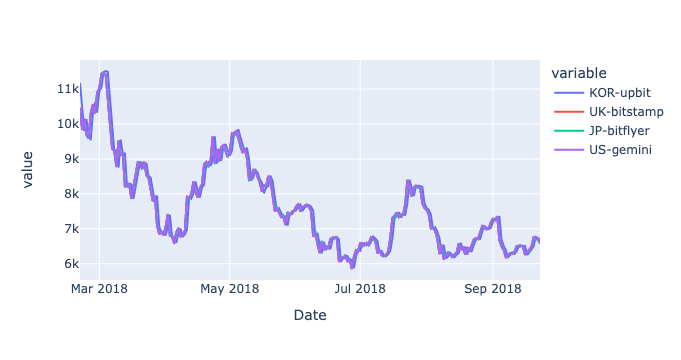

In [7]:
fig = px.line(kimchi_df, x=kimchi_df.index, y=list(kimchi_df.columns))
fig.update_traces(mode="lines", hovertemplate=None)
fig.update_layout(hovermode="x unified")
fig.show()

## 2. Price Deviations

We see deviations most clearly from KOR and US exchanges in the hundreds of USDs.  To further clarify this divergence, we plot the percent change of KOR, UK, and JP BTC prices against US prices.

In [8]:
from itertools import combinations
 
key_comb = combinations(list(kimchi_df.keys())[::-1], 2)
 
# Print the obtained combinations
for key_pair in list(key_comb):
    key1 = key_pair[0]
    key2 = key_pair[1]
    kimchi_df[f'{key1.split("-")[0]}-{key2.split("-")[0]}'] = (kimchi_df[key1] - kimchi_df[key2]) / kimchi_df[key1]

In [9]:
kimchi_df

,KOR-upbit,UK-bitstamp,JP-bitflyer,US-gemini,US-JP,US-UK,US-KOR,JP-UK,JP-KOR,UK-KOR
Date,,,,,,,,,,
2018-02-20,11182.0,10449.40,10446.40,10475.00,0.002730,0.002444,-0.067494,-0.000287,-0.070417,-0.070109
2018-02-21,10444.0,9843.34,9832.23,9829.96,-0.000231,-0.001361,-0.062466,-0.001130,-0.062221,-0.061022
2018-02-22,9800.0,10166.10,10153.90,10161.62,0.000760,-0.000441,0.035587,-0.001202,0.034854,0.036012
2018-02-23,10140.0,9689.99,9682.70,9697.21,0.001496,0.000745,-0.045662,-0.000753,-0.047229,-0.046441
2018-02-24,9699.5,9590.04,9580.60,9595.00,0.001501,0.000517,-0.010891,-0.000985,-0.012410,-0.011414
...,...,...,...,...,...,...,...,...,...,...
2018-09-19,6393.9,6492.98,6478.42,6495.87,0.002686,0.000445,0.015698,-0.002247,0.013046,0.015260
2018-09-20,6491.3,6749.45,6727.00,6759.51,0.004810,0.001488,0.039679,-0.003337,0.035038,0.038248
2018-09-21,6767.0,6710.01,6691.72,6710.26,0.002763,0.000037,-0.008456,-0.002733,-0.011250,-0.008493


In [10]:
kimchi_df.describe()

,KOR-upbit,UK-bitstamp,JP-bitflyer,US-gemini,US-JP,US-UK,US-KOR,JP-UK,JP-KOR,UK-KOR
count,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000
mean,7662.535185,7641.696435,7639.334444,7640.282083,0.000004,-0.000176,-0.003205,-0.000186,-0.003184,-0.003027
std,1298.327717,1274.390903,1267.967233,1273.425454,0.002815,0.001339,0.037384,0.002727,0.036583,0.037292
min,5867.100000,5848.330000,5885.800000,5850.130000,-0.013064,-0.008268,-0.122259,-0.008722,-0.121310,-0.121977
25%,6598.300000,6583.225000,6580.355000,6576.585000,-0.001112,-0.000781,-0.021609,-0.001802,-0.021714,-0.020943
50%,7400.900000,7375.305000,7389.215000,7383.215000,0.000247,-0.000133,0.000849,-0.000348,0.000931,-0.000960
75%,8435.250000,8422.040000,8408.852500,8414.807500,0.001541,0.000471,0.015063,0.001221,0.016718,0.015910
max,11520.000000,11463.270000,11481.000000,11467.190000,0.009140,0.007185,0.119488,0.011284,0.117838,0.119865


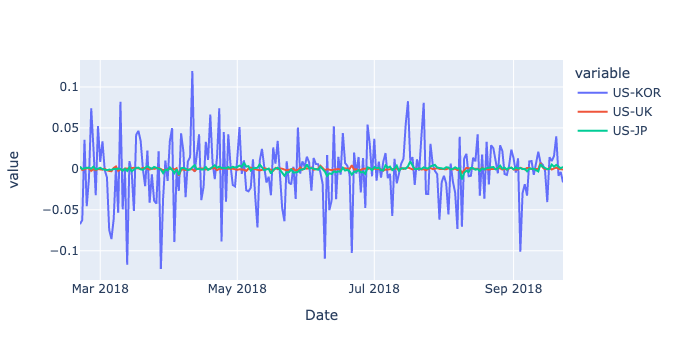

In [11]:
fig = px.line(kimchi_df, x=kimchi_df.index, y=list(kimchi_df.columns)[4:7][::-1])
fig.update_traces(mode="lines", hovertemplate=None)
fig.update_layout(hovermode="x unified")
fig.show()

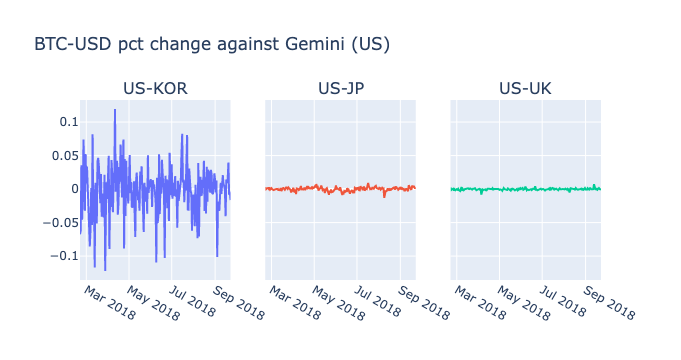

In [12]:
fig = make_subplots(
    rows=1, cols=3, 
    shared_yaxes=True,
    subplot_titles=("US-KOR","US-JP", "US-UK")
)
fig.add_trace(
    go.Scatter(x=kimchi_df.index, y=kimchi_df['US-KOR'],name='US-KOR'),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=kimchi_df.index, y=kimchi_df['US-JP'],name='US-JP'),
    row=1, col=2
)
fig.add_trace(
    go.Scatter(x=kimchi_df.index, y=kimchi_df['US-UK'],name='US-UK'),
    row=1, col=3
)
fig.update_layout(title_text="BTC-USD pct change against Gemini (US)", showlegend=False)
fig.show()

We observe significant volatility in US-KOR spread versus US-JP and US-UK. The Kimchi Premium (US-KOR) during 2018 reached a maximum of +/-12% with 3.7% volatility, a significantly divergence in price.

This could present a theoretical CEX arbitrage opportunity, which we now explore.

## 3. Testing for Stationarity

We focus on US-KOR spread. To arbitrage this spread, we first need to test for its stationarity. We will use a simplified Dickey-Fuller test with 100 observations with the null hypothesis being US-KOR spread is not stationary.

In [68]:
def linearRegression(df, samples):
    training_df = df[:samples+1]
    # spread
    y = training_df['US-gemini'] - training_df['KOR-upbit']
    # delta, use shift(-1) to have X lag one day prior to y 
    X = (y.shift(-1) - y)
    # avoid NaN
    X = X[:-1]
    y = y[:-1]
    # add constant
    X = sm.add_constant(X)
    model = sm.OLS(y, X)
    results = model.fit()
    print(results.summary())

In [69]:
linearRegression(kimchi_df, 100)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.517
Method:                 Least Squares   F-statistic:                     107.1
Date:                Sun, 12 Mar 2023   Prob (F-statistic):           2.10e-17
Time:                        21:53:30   Log-Likelihood:                -696.20
No. Observations:                 100   AIC:                             1396.
Df Residuals:                      98   BIC:                             1402.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -34.5821     25.809     -1.340      0.1

To determine stationarity, one way is to compare t stat of the variable with the D-F table below.

|                          | critical | t stat (n=100) |
|--------------------------|----------|----------------|
| w/ constant              |          |                |
|                          | 2%       | -3.51          |
|                          | 5%       | -3.17          |
|                          | 10%      | -2.58          |
| w/ constant + time trend |          |                |
|                          | 2%       | -4.04          |
|                          | 5%       | -3.69          |
|                          | 10%      | -3.15          |

With t stat of -10.35 for the variable less than -4.04 for time trend series with 100 observations, we have evidence to reject the null hypothesis that US-KOR is not stationary.

To do: proper regression analysis (qq, leverage, outliers)

## 4. Spread Arbitrage
